# Read and stack multiple dates into a single data array

In this example, we use MODIS SST data (`.nc` NetCDF files) to demonstrate how you can stack together many dates of imagery into a single data cube using xarray (`xr.open_dataset()` and `xr.concat()`)

**This example was created by Jack Dechow.**

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import glob
import pandas as pd
from pathlib import Path

In [2]:
# Assign file directory to variable
fdir = "MODIS_SST/"
# Use file directory and Path() to find all netCDF files in data directory
files = sorted(Path(fdir).glob("*.nc"))
# Print all files found
print(files)

# Create dataset variable for later
datasets = []

# Use for loop to read in files and fix some attribute issues
for f in files:
    # Print first file name as example
    print(f)
    # First issue is these monthly MODIS files do not have a time variable
    # So we need to extract a date value from the file name
    # The file names are long so first we split the file at the `_` character between the dates
    # And we take the latter half
    tmpstr = f.stem.split("_")[-1]  

    # print split file as example
    print(tmpstr)
    # Now we repeat the same thing but with the `.` character
    datestr = tmpstr.split(".")[0]

    # Then convert to pandas datetime
    time = pd.to_datetime(datestr, format="%Y%m%d")  # end of month time
    print(time)

    # Open first file as ds
    ds = xr.open_dataset(f)
    # Remove palette var from ds
    tmp_ds = ds.drop_vars('palette')
    ds = tmp_ds
    # Add a time dimension to ds
    ds = ds.expand_dims(time=[time])
    # Append most recently read file to the end of the dataset
    datasets.append(ds)

# Concatenate the many appended datasets into a single multipage (lat lon time) array
combined = xr.concat(datasets, dim="time")

[PosixPath('MODIS_SST/AQUA_MODIS.20120101_20120131.L3m.MO.SST.sst.4km.nc'), PosixPath('MODIS_SST/AQUA_MODIS.20120201_20120229.L3m.MO.SST.sst.4km.nc')]
2012-01-31 00:00:00
2012-02-29 00:00:00


In [3]:
# Extract only the sea surface temp dataarray from the dataset
sst = combined['sst']

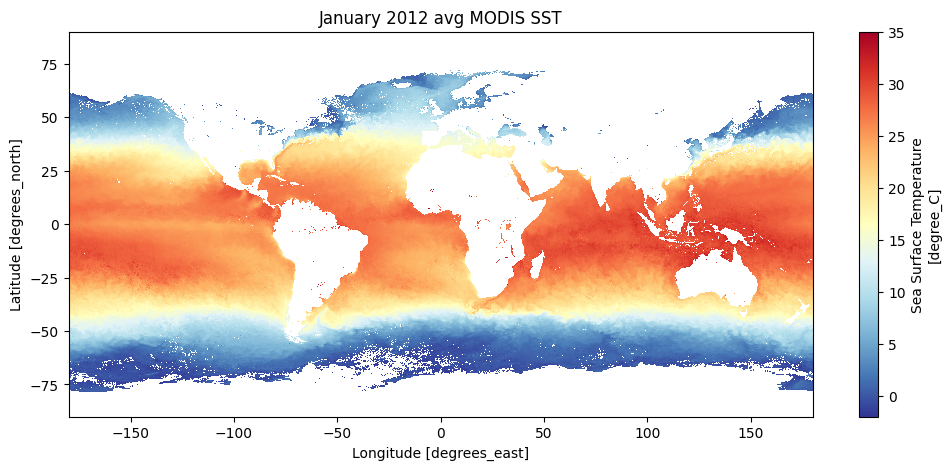

In [4]:
# use isel (integer select) to grab the first month data in the array
# put it in var sst1
sst1 = sst.isel(time = 0)

# plot to confirm we did it right
h = sst1.plot(cmap = 'RdYlBu_r', figsize=(12,5))
plt.title("January 2012 avg MODIS SST")
h.set_clim(-2, 35)
plt.show()